<a href="https://colab.research.google.com/github/ierigeri/Practica-1/blob/Tranque-el-mauro/prueba%20muy%20cerca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import platform, sys, os
if 'google.colab' in sys.modules:
    # install PyGMTSAR stable version from PyPI
    !{sys.executable} -m pip install -q pygmtsar 'scipy==1.11.4'
    import importlib.resources as resources
    with resources.as_file(resources.files('pygmtsar.data') / 'google_colab.sh') as google_colab_script_filename:
        !sh {google_colab_script_filename}
    # enable custom widget manager as required by recent Google Colab updates
    from google.colab import output
    output.enable_custom_widget_manager()
    # initialize virtual framebuffer for interactive 3D visualization; required for headless environments
    import xvfbwrapper
    display = xvfbwrapper.Xvfb(width=800, height=600)
    display.start()

# specify GMTSAR installation path
PATH = os.environ['PATH']
if PATH.find('GMTSAR') == -1:
    PATH = os.environ['PATH'] + ':/usr/local/GMTSAR/bin/'
    %env PATH {PATH}

# display PyGMTSAR version
from pygmtsar import __version__
__version__

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.6/97.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 k

'2024.8.30.post5'

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import json
import shapely
from dask.distributed import Client
import psutil
import dask

In [ ]:
# plotting modules
import pyvista as pv
# magic trick for white background
pv.set_plot_theme("document")
import panel
panel.extension(comms='ipywidgets')
panel.extension('vtk')
from contextlib import contextmanager
import matplotlib.pyplot as plt
@contextmanager
def mpl_settings(settings):
    original_settings = {k: plt.rcParams[k] for k in settings}
    plt.rcParams.update(settings)
    yield
    plt.rcParams.update(original_settings)
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
%matplotlib inline

In [ ]:
# define Pandas display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

In [ ]:
from pygmtsar import S1, Stack, tqdm_dask, ASF, Tiles, XYZTiles

Procesamiento de Imágenes Sentinel-1


In [ ]:
ORBIT        = 'D'
SUBSWATH     = 2

In [ ]:
SCENES = ['S1A_IW_SLC__1SDV_20231228T100413_20231228T100440_051853_0643A1_8714',
          'S1A_IW_SLC__1SDV_20241104T100411_20241104T100438_056403_06E93C_8550',
          'S1A_IW_SLC__1SDV_20240601T100412_20240601T100439_054128_069509_A18D']
SUBSWATH = 2

In [ ]:
WORKDIR      = 'raw_kal'
DATADIR      = 'data_kal'

In [ ]:
# define DEM and landmask filenames inside data directory
DEM = f'{DATADIR}/dem_alta_resolucion.nc'

In [ ]:
geojson = '''
{
  "type": "Feature",
  "geometry": {
    "type": "LineString",
    "coordinates": [[-71.113, -31.9206], [-71.113, -32.0107], [-70.9305, -31.9894],
                    [-70.9916, -31.9395], [-71.0668, -31.9405]]
  },
  "properties": {}
}
'''
AOI = gpd.GeoDataFrame.from_features([json.loads(geojson)])

In [ ]:
# Set these variables to None and you will be prompted to enter your username and password below.
asf_username = 'GoogleColab2023'
asf_password = 'GoogleColab_2023'

In [ ]:
# Set these variables to None and you will be prompted to enter your username and password below.
asf = ASF(asf_username, asf_password)
# Optimized scene downloading from ASF - only the required subswaths and polarizations.
# Subswaths are already encoded in burst identifiers and are only needed for scenes.
print(asf.download(DATADIR, SCENES, SUBSWATH))


ASF Downloading Sentinel-1 SLC::   0%|          | 0/3 [00:00<?, ?it/s]

                                                        burst_or_scene
0  S1A_IW_SLC__1SDV_20231228T100413_20231228T100440_051853_0643A1_8714
1  S1A_IW_SLC__1SDV_20241104T100411_20241104T100438_056403_06E93C_8550
2  S1A_IW_SLC__1SDV_20240601T100412_20240601T100439_054128_069509_A18D


In [ ]:
S1.download_orbits(DATADIR, S1.scan_slc(DATADIR))

,orbit
0,S1A_OPER_AUX_POEORB_OPOD_20240117T070858_V20231227T225942_20231229T005942.EOF.zip
1,S1A_OPER_AUX_POEORB_OPOD_20240621T070825_V20240531T225942_20240602T005942.EOF.zip
2,S1A_OPER_AUX_POEORB_OPOD_20241124T070605_V20241103T225942_20241105T005942.EOF.zip


NOTE: Target file exists, return it. Use "skip_exist=False" or omit the filename to allow new downloading.


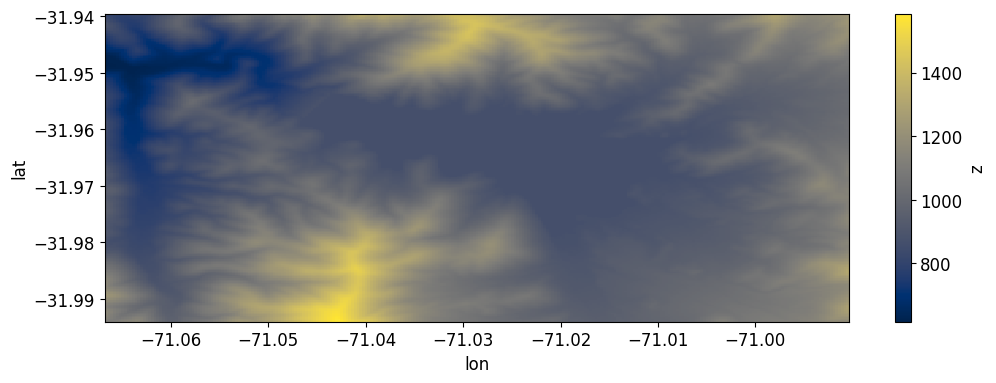

In [ ]:
Tiles().download_dem(AOI, filename=DEM).plot.imshow(cmap='cividis')


In [ ]:
# simple Dask initialization
if 'client' in globals():
    client.close()
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:42233
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33295'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33143'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:35843', name: 1, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35843
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:32978
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:32871', name: 0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker co

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42233,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 2
Started: Just now,Total memory: 12.67 GiB
Comm: tcp://127.0.0.1:32871,Total threads: 1
Dashboard: http://127.0.0.1:35503/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:33295,


In [ ]:
scenes = S1.scan_slc(DATADIR, subswath=SUBSWATH)

In [ ]:
sbas = Stack(WORKDIR, drop_if_exists=True).set_scenes(scenes)
sbas.to_dataframe()


NOTE: auto set reference scene 2023-12-28. You can change it like Stack.set_reference("2022-01-20")


,datetime,orbit,mission,polarization,subswath,datapath,metapath,noisepath,calibpath,orbitpath,geometry
date,,,,,,,,,,,
2023-12-28,2023-12-28 10:04:14,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20231228T100413_20231228T100440_051853_0643A1_8714.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20231228T100413_20231228T100440_051853_0643A1_8714.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_POEORB_OPOD_20240117T070858_V20231227T225942_20231229T005942.EOF,"MULTIPOLYGON (((-70.4969 -31.4173, -70.54948 -31.40491, -70.60249 -31.39239, -70.65096 -31.38094..."
2024-06-01,2024-06-01 10:04:14,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20240601T100412_20240601T100439_054128_069509_A18D.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20240601T100412_20240601T100439_054128_069509_A18D.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_POEORB_OPOD_20240621T070825_V20240531T225942_20240602T005942.EOF,"MULTIPOLYGON (((-70.4956 -31.41725, -70.54819 -31.40486, -70.60121 -31.39235, -70.64969 -31.3808..."
2024-11-04,2024-11-04 10:04:13,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20241104T100411_20241104T100438_056403_06E93C_8550.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20241104T100411_20241104T100438_056403_06E93C_8550.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_POEORB_OPOD_20241124T070605_V20241103T225942_20241105T005942.EOF,"MULTIPOLYGON (((-70.49797 -31.41744, -70.55055 -31.40505, -70.60356 -31.39253, -70.65204 -31.381..."


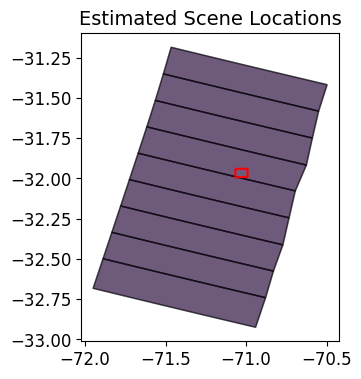

In [ ]:
sbas.plot_scenes(AOI=AOI, aspect='equal')


In [ ]:
sbas.compute_reframe(AOI)


Reframing:   0%|          | 0/3 [00:00<?, ?it/s]

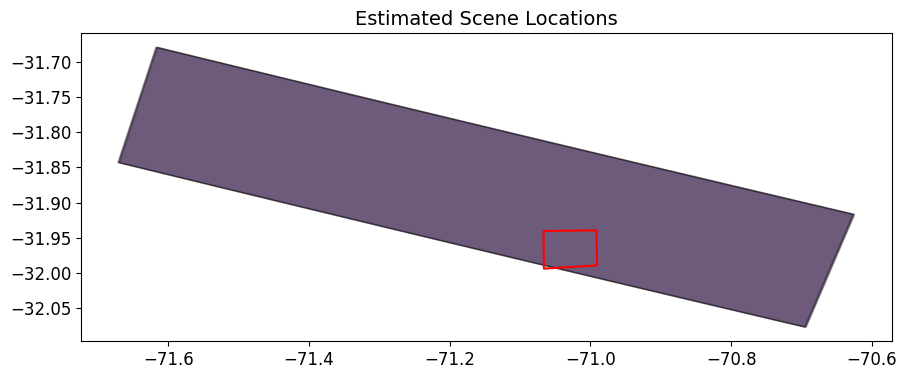

In [ ]:
sbas.plot_scenes(AOI=AOI, aspect='equal')

In [ ]:
sbas.load_dem(DEM, AOI)

Save DEM on WGS84 Ellipsoid:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

INFO:distributed.scheduler:Receive client connection: Client-worker-aaee58b2-d2b9-11ef-980f-0242ac1c0002
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:57034


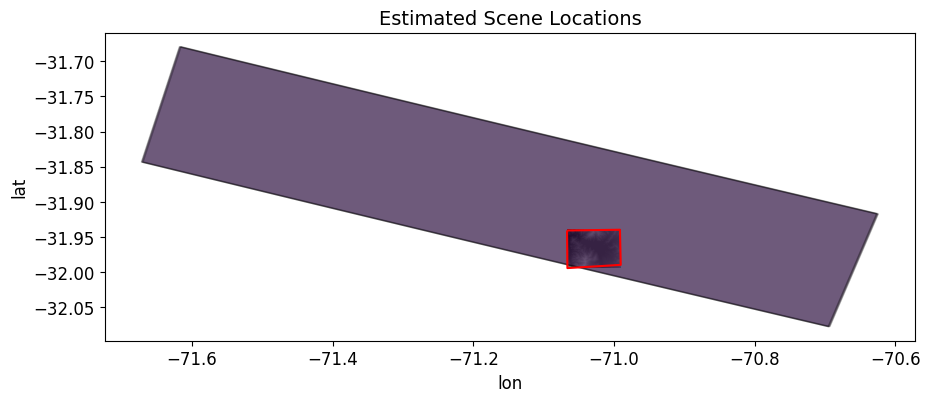

In [ ]:
sbas.plot_scenes(AOI=AOI, aspect='equal')

In [ ]:
sbas.compute_align()

Preparing Reference:   0%|          | 0/1 [00:00<?, ?it/s]

Aligning Repeat:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
sbas.compute_geocode(45.)

Radar Transform Computing:   0%|          | 0/1 [00:00<?, ?it/s]

Radar Transform Saving:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

Radar Transform Indexing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

Radar Inverse Transform Computing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

Satellite Look Vector Computing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

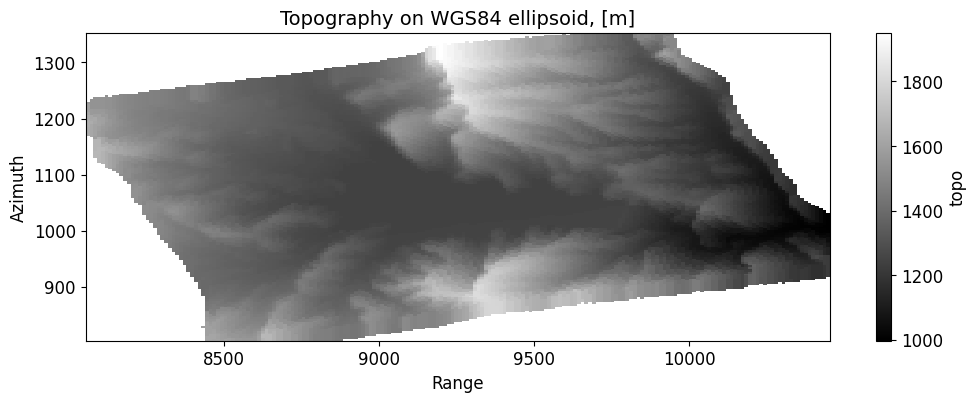

In [ ]:
sbas.plot_topo()
plt.savefig('Topography in Radar Coordinates.jpg', dpi=300)

In [ ]:
# define two correlation maps
pairs = np.asarray([sbas.to_dataframe().index[:-1], sbas.to_dataframe().index[1:]])
pairs

array([['2023-12-28', '2024-06-01'],
       ['2024-06-01', '2024-11-04']], dtype=object)

In [ ]:
# load radar topography
topo = sbas.get_topo()
# load Sentinel-1 data
data = sbas.open_data()
intensity = sbas.multilooking(np.square(np.abs(data)), wavelength=400, coarsen=(3,12))
# calculate phase difference with topography correction
phase = sbas.phasediff(pairs, data, topo)
phase = sbas.multilooking(phase, wavelength=400, coarsen=(3,12))
corr = sbas.correlation(phase, intensity)
# materialize
tqdm_dask(corr := dask.persist(corr)[0], desc='Compute Correlation')
corr

Compute Correlation:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

<xarray.DataArray 'correlation' (pair: 2, y: 183, x: 199)> Size: 291kB
dask.array<concatenate, shape=(2, 183, 199), dtype=float32, chunksize=(1, 183, 199), chunktype=numpy.ndarray>
Coordinates:
    ref      (pair) datetime64[ns] 16B 2023-12-28 2024-06-01
    rep      (pair) datetime64[ns] 16B 2024-06-01 2024-11-04
  * pair     (pair) <U21 168B '2023-12-28 2024-06-01' '2024-06-01 2024-11-04'
  * y        (y) float64 1kB 804.5 807.5 810.5 ... 1.344e+03 1.348e+03 1.35e+03
  * x        (x) float64 2kB 8.064e+03 8.076e+03 ... 1.043e+04 1.044e+04

In [ ]:
# geocode
corr_ll = sbas.ra2ll(corr)

In [ ]:
# prepare topography and correlation
dem = sbas.get_dem().interp_like(corr_ll).where(np.isfinite(corr_ll.mean('pair')))
gmap = XYZTiles().download(dem, 12)
#.interp_like(corr_ll)

XYZ Tiles Downloading:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
sbas.export_vtk(corr_ll[0], 'before', image=gmap)
sbas.export_vtk(corr_ll[1], 'after',  image=gmap)

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
plotter = pv.Plotter(shape=(1, 2), notebook=True)
axes = pv.Axes(show_actor=True, actor_scale=2.0, line_width=5)

def read_mesh(name):
    mesh = pv.read(f'{name}.vtk').scale([1, 1, 0.00005], inplace=True).rotate_z(135, point=axes.origin, inplace=True)
    correlation_data = mesh['correlation']
    opacity_data = np.ones_like(correlation_data, dtype=np.float64)  # Initialize with all values as 1.0 (fully opaque)
    opacity_data[correlation_data < 0.2] = 0.0
    opacity_normalized = (opacity_data - opacity_data.min()) / (opacity_data.max() - opacity_data.min())
    combined_scalars = np.column_stack((mesh['colors'], opacity_normalized))
    mesh['colors'][correlation_data < 0.15] = [70, 130, 180]
    return mesh

plotter.subplot(0, 0)
plotter.add_mesh(read_mesh('before'), scalars='colors', rgb=True, ambient=0.2)
plotter.add_title(f'Tranque el Mauro', font_size=32)

plotter.show_axes()
plotter.show(screenshot='Interactive Sentinel-1 Flooding Map.png', jupyter_backend='panel', return_viewer=True)
plotter._on_first_render_request()
panel.panel(
    plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
    enable_keybindings=False, sizing_mode='stretch_width', min_height=600
)

VTKRenderWindowSynchronized(vtkXOpenGLRenderWindow, min_height=600, orientation_widget=True, sizing_mode='stretch_width')

In [ ]:
a

In [ ]:
# for a pair of scenes only two interferograms can be produced
# this one is selected for scenes sorted by the date in direct order
pairs = [[sbas.to_dataframe().index[i], sbas.to_dataframe().index[i+1]] for i in range(len(sbas.to_dataframe().index)-1)]
pairs

[['2023-12-28', '2024-06-01'], ['2024-06-01', '2024-11-04']]

In [ ]:
# load radar topography
topo = sbas.get_topo()
# load Sentinel-1 data
data = sbas.open_data()
# Gaussian filtering 200m cut-off wavelength with multilooking 1x4 on Sentinel-1 intensity
intensity15m = sbas.multilooking(np.square(np.abs(data)), wavelength=200, coarsen=(1,4))
# calculate phase difference with topography correction
phase = sbas.phasediff(pairs, data, topo)
# Gaussian filtering 400m cut-off wavelength with 1:4 range multilooking
phase15m = sbas.multilooking(phase, wavelength=200, coarsen=(1,4))
# correlation with 1:4 range decimation to about 15m resolution
corr15m = sbas.correlation(phase15m, intensity15m)
# Goldstein filter in 32 pixel patch size on square grid cells produced using 1:4 range multilooking
phase15m_goldstein = sbas.goldstein(phase15m, corr15m, 32)
# convert complex phase difference to interferogram
intf15m = sbas.interferogram(phase15m_goldstein)
# decimate the 1:4 multilooking grids to 60m resolution
decimator = sbas.decimator()
# compute together because correlation depends on phase, and filtered phase depends on correlation.
tqdm_dask(result := dask.persist(decimator(corr15m), decimator(intf15m)), desc='Compute Phase and Correlation')
# unpack results for a single interferogram
corr60m, intf60m = [grid[0] for grid in result]

Compute Phase and Correlation:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

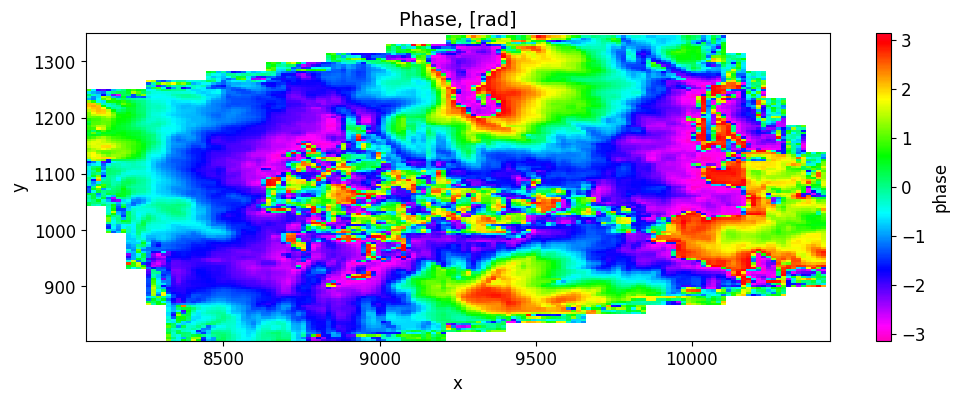

In [ ]:
sbas.plot_interferogram(intf60m)
plt.savefig('Phase, [rad].jpg')

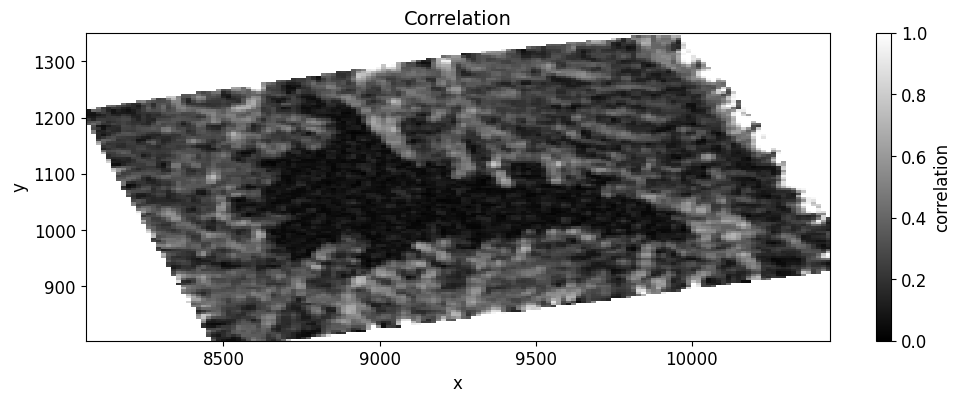

In [ ]:
sbas.plot_correlation(corr60m)
plt.savefig('Correlation.jpg')

In [ ]:
sbas.export_vtk(intf60m[::3,::3], 'intf')

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# build interactive 3D plot
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(pv.read('intf.vtk').scale([1, 1, 0.00002], inplace=True), scalars='phase', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.show_axes()
plotter.show(screenshot='3D Interferogram.png', jupyter_backend='panel', return_viewer=True)
plotter.add_title(f'Interactive Interferogram on DEM', font_size=32)
plotter._on_first_render_request()
panel.panel(
    plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
    enable_keybindings=False, sizing_mode='stretch_width', min_height=600
)

VTKRenderWindowSynchronized(vtkXOpenGLRenderWindow, color_mappers=[LinearColorMapper(id='d05...], min_height=600, orientation_widget=True, sizing_mode='stretch_width')

In [ ]:
# mask low-coherence areas using threshold value 0.1
tqdm_dask(unwrap := sbas.unwrap_snaphu(intf60m, corr60m.where(corr60m>=0.1)).persist(), desc='SNAPHU Unwrapping')

SNAPHU Unwrapping:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

In [ ]:
# geocode to geographic coordinates and crop empty borders
unwrap_ll = sbas.cropna(sbas.ra2ll(unwrap.phase))

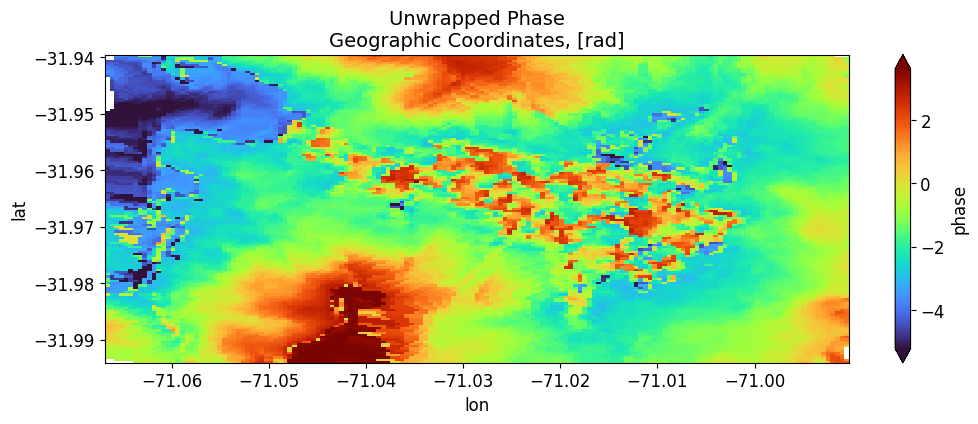

In [ ]:
sbas.plot_phase(unwrap_ll, caption='Unwrapped Phase\nGeographic Coordinates, [rad]', quantile=[0.01, 0.99])

In [ ]:
# geocode to geographic coordinates and crop empty borders
los_disp_mm_ll = sbas.cropna(sbas.ra2ll(sbas.los_displacement_mm(unwrap.phase)))

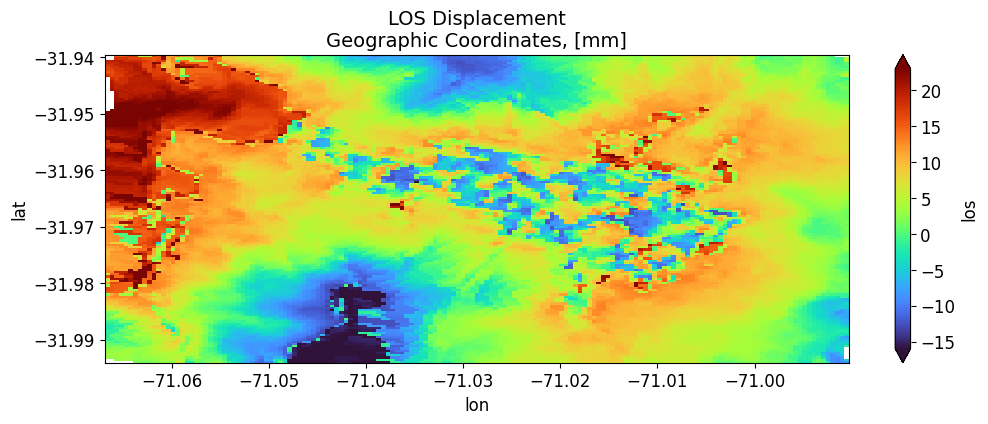

In [ ]:
sbas.plot_displacement(los_disp_mm_ll, caption='LOS Displacement\nGeographic Coordinates, [mm]', quantile=[0.01, 0.99])
plt.savefig('LOS Displacement Geographic Coordinates, [mm].jpg')

In [ ]:
sbas.export_vtk(los_disp_mm_ll[::3,::3], 'los')

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# save the results
corr60m.to_netcdf('los_disp_mm_ll.nc', engine=sbas.netcdf_engine)

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('los_disp_mm_ll.nc')
    files.download('intf.vtk')
    files.download('los.vtk')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>